# Student Dropout Prediction
> Exploratory Data Analysis, preprocessing, model training,
evaluation, and feature importance analysis.

In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

In [3]:
CAT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
DATA_PATH = "../data/students.csv"
MODEL_DIR = "../model"
STATIC_DIR = "../static"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(STATIC_DIR, exist_ok=True)

## Load Data

In [4]:
df = pd.read_csv(DATA_PATH)

In [5]:
print("Shape:", df.shape)
df.head()

Shape: (5000, 19)


,student_id,age,gender,family_income_level,parental_education,distance_from_home_km,has_scholarship,part_time_job,high_school_gpa,entrance_exam_score,prior_failures,semester,attendance_rate,study_hours_per_week,current_gpa,lms_login_freq_per_week,extracurricular_activities,counseling_visits,dropout
0,S100000,18,Male,Medium,Bachelor,2.7,0,1,2.33,56.9,0,4,81.3,21.9,2.50,4.0,1,0,0
1,S100001,27,Female,Medium,NaN,9.9,0,0,2.86,55.5,0,3,71.7,11.2,3.25,6.0,1,0,0
2,S100002,25,Female,Low,Secondary,3.9,0,1,2.84,40.8,0,1,70.9,9.1,2.14,11.0,0,0,1
3,S100003,22,Female,Medium,Bachelor,28.0,1,1,3.04,70.9,0,4,88.7,9.8,2.72,7.0,1,1,0
4,S100004,22,Male,Medium,Bachelor,5.4,0,1,2.97,72.4,0,2,80.0,16.8,2.85,7.0,1,0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   object 
 1   age                         5000 non-null   int64  
 2   gender                      5000 non-null   object 
 3   family_income_level         5000 non-null   object 
 4   parental_education          4256 non-null   object 
 5   distance_from_home_km       5000 non-null   float64
 6   has_scholarship             5000 non-null   int64  
 7   part_time_job               5000 non-null   int64  
 8   high_school_gpa             5000 non-null   float64
 9   entrance_exam_score         5000 non-null   float64
 10  prior_failures              5000 non-null   int64  
 11  semester                    5000 non-null   int64  
 12  attendance_rate             5000 non-null   float64
 13  study_hours_per_week        5000 

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,5000,5000,S100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,22.9824,3.754638,17.0,20.0,23.0,26.0,29.0
gender,5000,2,Female,2957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_income_level,5000,3,Medium,2288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental_education,4256,3,Secondary,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_from_home_km,5000.0,NaN,NaN,NaN,15.17272,15.39466,0.0,4.2,10.7,21.2,157.4
has_scholarship,5000.0,NaN,NaN,NaN,0.3034,0.459772,0.0,0.0,0.0,1.0,1.0
part_time_job,5000.0,NaN,NaN,NaN,0.4512,0.497663,0.0,0.0,0.0,1.0,1.0
high_school_gpa,5000.0,NaN,NaN,NaN,2.996078,0.491629,1.29,2.66,2.99,3.34,4.0
entrance_exam_score,5000.0,NaN,NaN,NaN,64.51194,14.991435,20.0,54.5,64.5,74.6,100.0


## Data Quality Check

In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None")
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
parental_education    744
dtype: int64
Duplicate rows: 0


## Target Variable Distribution

In [9]:
counts = df["dropout"].value_counts().sort_index()
pct = counts / counts.sum() * 100

print("Class distribution:")
print(pct.round(2))

Class distribution:
dropout
0    64.26
1    35.74
Name: count, dtype: float64


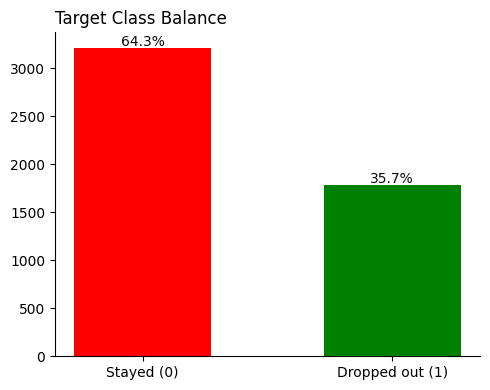

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Stayed (0)", "Dropped out (1)"],
    counts.values,
    color=["red", "green"],
    width=0.55,
)

for bar, percentage in zip(bars, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{percentage:.1f}%",
        ha="center",
        color="#0b0b0b",
        fontsize=10,
    )

ax.set_title("Target Class Balance", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Univariate Analysis — Numerical Features

In [11]:
numeric_cols = [
    "age", "distance_from_home_km", "high_school_gpa",
    "entrance_exam_score", "prior_failures", "attendance_rate",
    "study_hours_per_week", "current_gpa",
    "lms_login_freq_per_week", "counseling_visits",
]

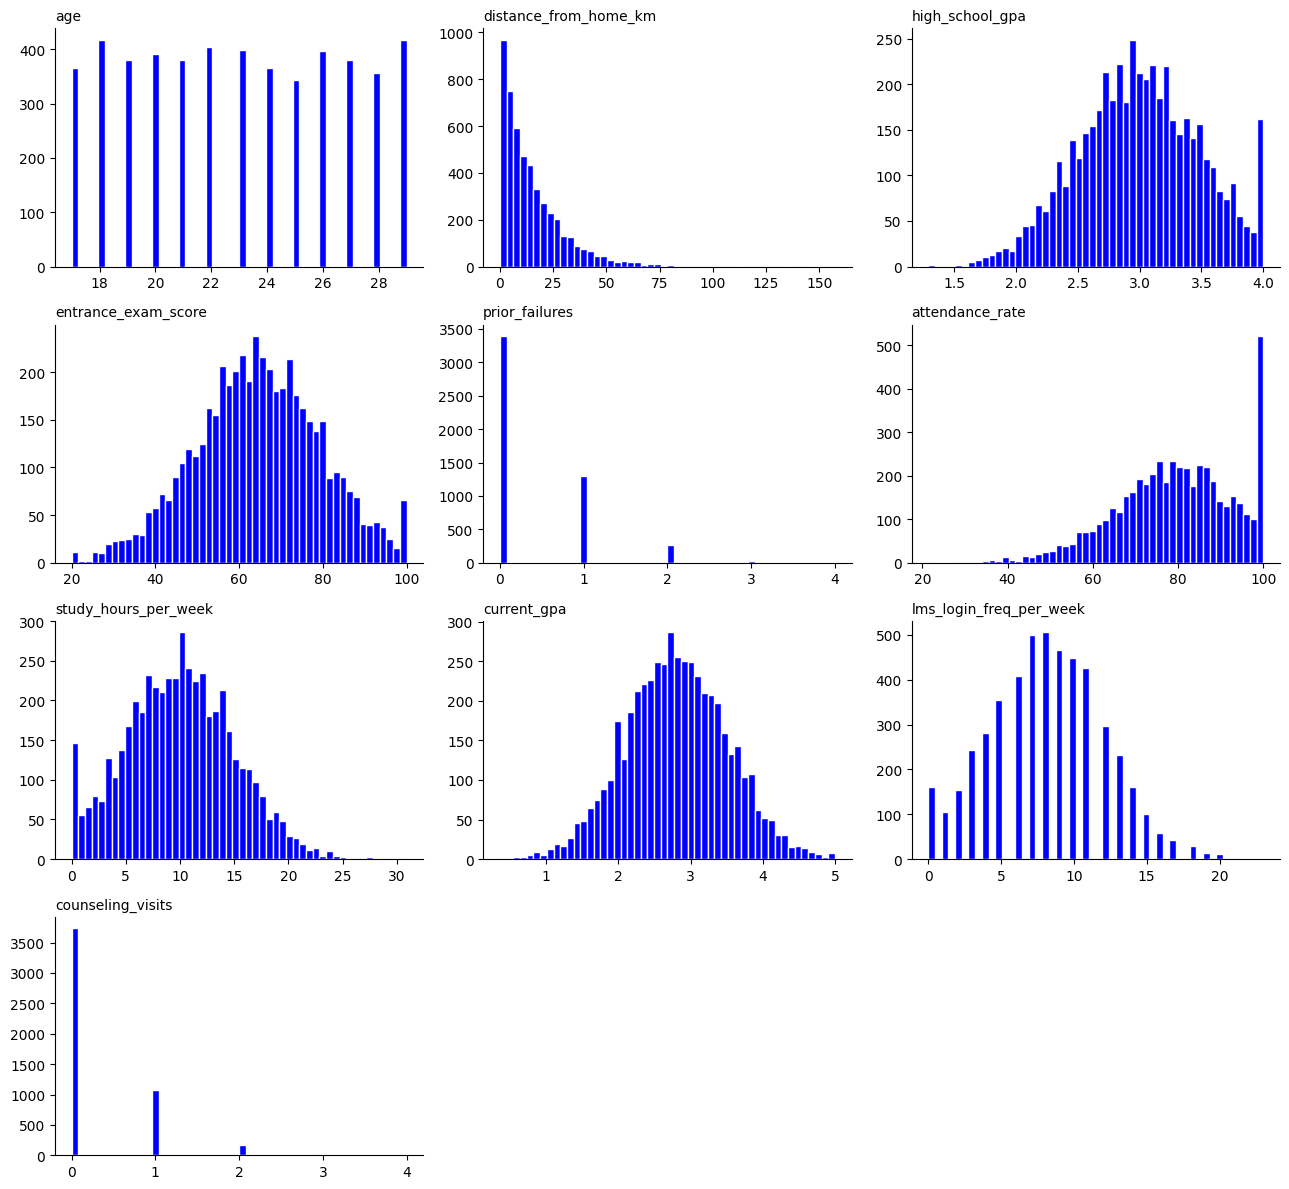

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=50, color="blue", edgecolor="#fcfcfb")
    axes[i].set_title(col, loc="left", fontsize=10)
    axes[i].spines[["top", "right"]].set_visible(False)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Univariate Analysis — Categorical Features

In [13]:
cat_cols = [
    "gender", "family_income_level", "parental_education",
    "has_scholarship", "part_time_job", "extracurricular_activities",
]

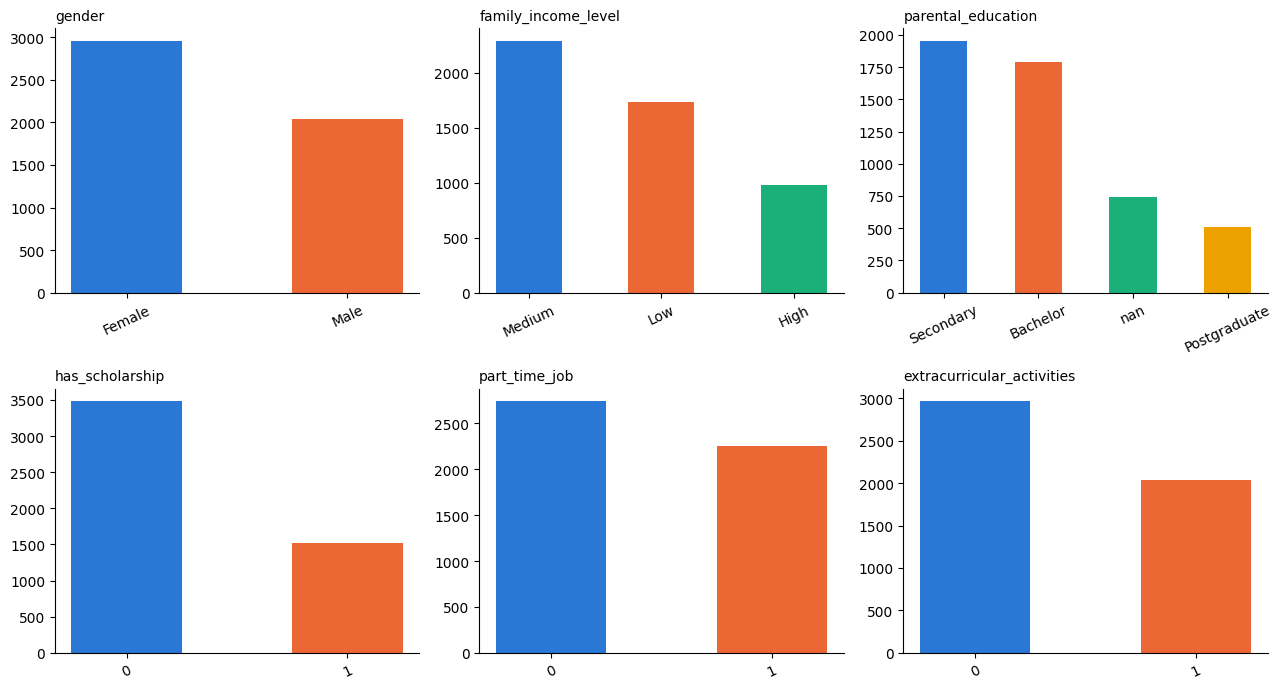

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].astype(str).value_counts()
    colors = [CAT_COLORS[j % len(CAT_COLORS)] for j in range(len(vc))]
    axes[i].bar(vc.index, vc.values, color=colors, width=0.5)
    axes[i].set_title(col, loc="left", fontsize=10)
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Bivariate Analysis — Numerical Features vs Dropout

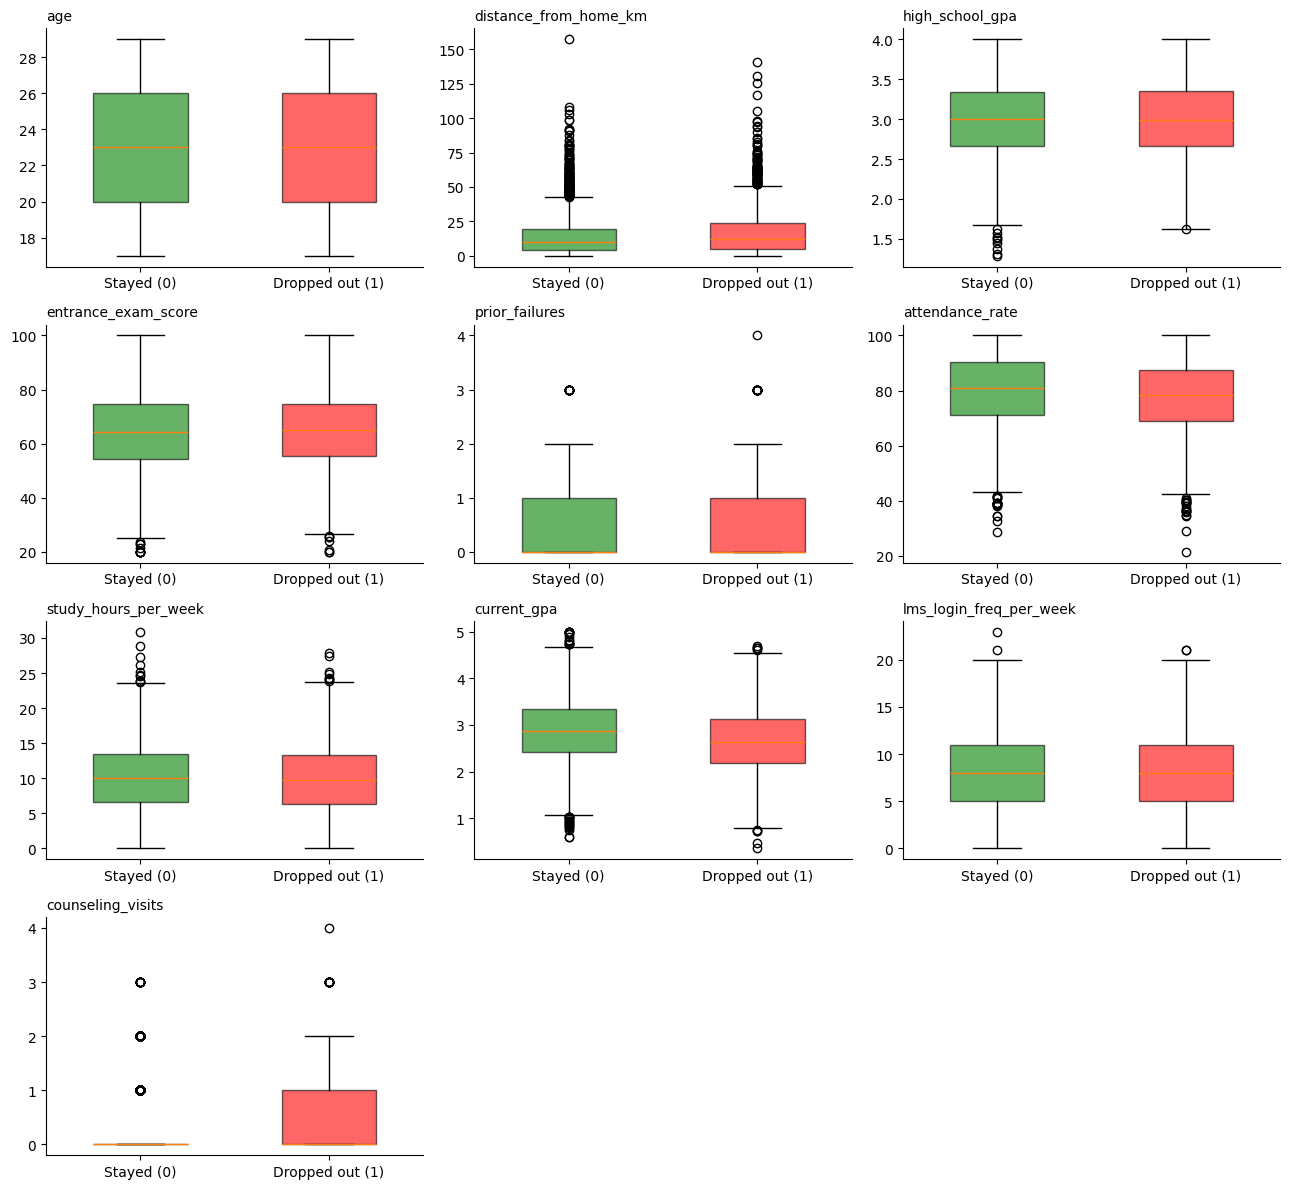

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data0 = df.loc[df["dropout"] == 0, col]
    data1 = df.loc[df["dropout"] == 1, col]

    bp = axes[i].boxplot(
        [data0, data1],
        tick_labels=["Stayed (0)", "Dropped out (1)"],
        patch_artist=True,
        widths=0.5,
    )

    for patch, color in zip(bp["boxes"], ["green", "red"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[i].set_title(col, loc="left", fontsize=10)
    axes[i].spines[["top", "right"]].set_visible(False)

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Bivariate Analysis — Categorical Features vs Dropout Rate

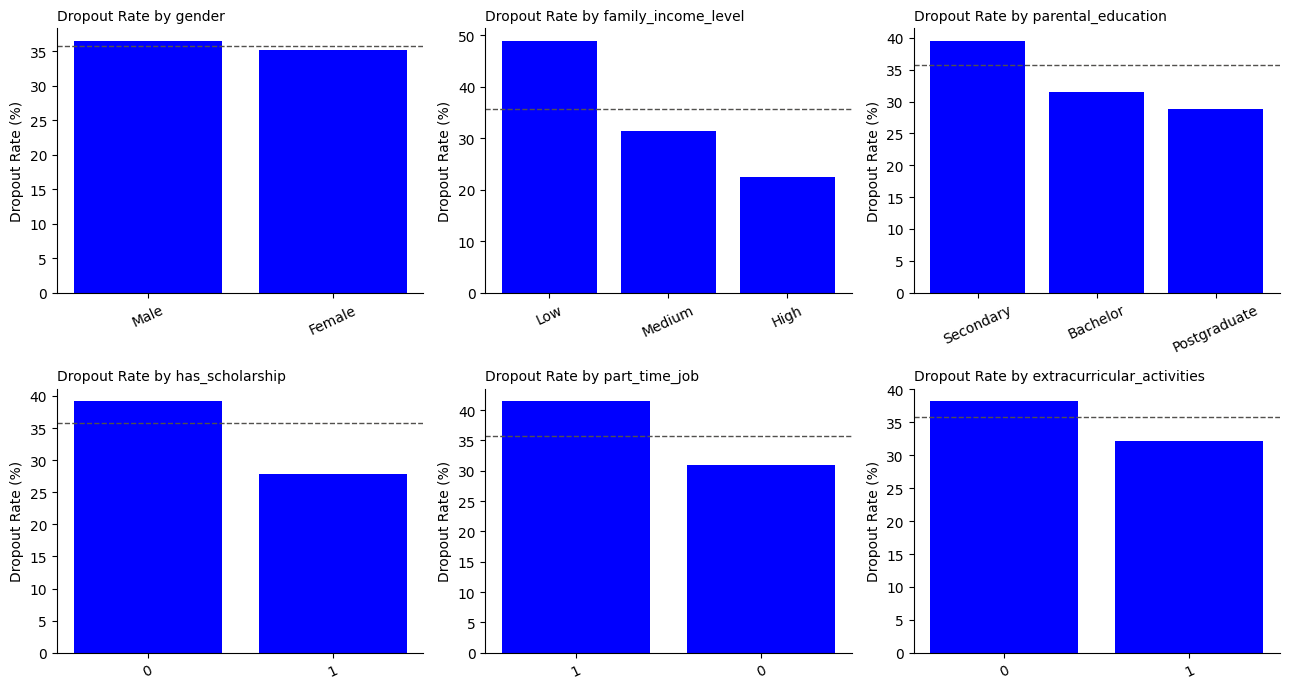

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

overall_dropout_rate = df["dropout"].mean() * 100

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)["dropout"].mean().sort_values(ascending=False) * 100

    axes[i].bar(rate.index.astype(str), rate.values, color="blue")
    axes[i].axhline(
        overall_dropout_rate,
        color="#52514e",
        linestyle="dashed",
        linewidth=1,
    )
    axes[i].set_title(f"Dropout Rate by {col}", loc="left", fontsize=10)
    axes[i].set_ylabel("Dropout Rate (%)")
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [17]:
print(
    f"Dashed line = overall average dropout rate "
    f"({overall_dropout_rate:.2f}%)"
)

Dashed line = overall average dropout rate (35.74%)


## Correlation Heatmap

In [18]:
corr_cols = numeric_cols + ["dropout"]
corr = df[corr_cols].corr()
corr

,age,distance_from_home_km,high_school_gpa,entrance_exam_score,prior_failures,attendance_rate,study_hours_per_week,current_gpa,lms_login_freq_per_week,counseling_visits,dropout
age,1.000000,-0.035186,0.013104,-0.025839,0.005589,0.031717,-0.014700,0.013886,-0.014998,-0.011545,-0.014179
distance_from_home_km,-0.035186,1.000000,0.008017,0.000668,-0.015768,-0.019760,0.012118,0.016499,0.006041,0.007449,0.092669
high_school_gpa,0.013104,0.008017,1.000000,0.001274,-0.001491,0.016632,-0.008119,-0.026394,-0.004693,0.013959,0.005330
entrance_exam_score,-0.025839,0.000668,0.001274,1.000000,0.006158,-0.004841,0.002028,0.002362,-0.005781,0.032515,0.017887
prior_failures,0.005589,-0.015768,-0.001491,0.006158,1.000000,-0.004884,0.005711,-0.019870,-0.003017,0.010864,0.079325
attendance_rate,0.031717,-0.019760,0.016632,-0.004841,-0.004884,1.000000,-0.004844,-0.006019,-0.008817,0.004295,-0.080541
study_hours_per_week,-0.014700,0.012118,-0.008119,0.002028,0.005711,-0.004844,1.000000,0.011490,-0.032002,-0.025296,-0.010471
current_gpa,0.013886,0.016499,-0.026394,0.002362,-0.019870,-0.006019,0.011490,1.000000,0.013326,-0.006826,-0.157557
lms_login_freq_per_week,-0.014998,0.006041,-0.004693,-0.005781,-0.003017,-0.008817,-0.032002,0.013326,1.000000,-0.002790,-0.005664
counseling_visits,-0.011545,0.007449,0.013959,0.032515,0.010864,0.004295,-0.025296,-0.006826,-0.002790,1.000000,0.034540


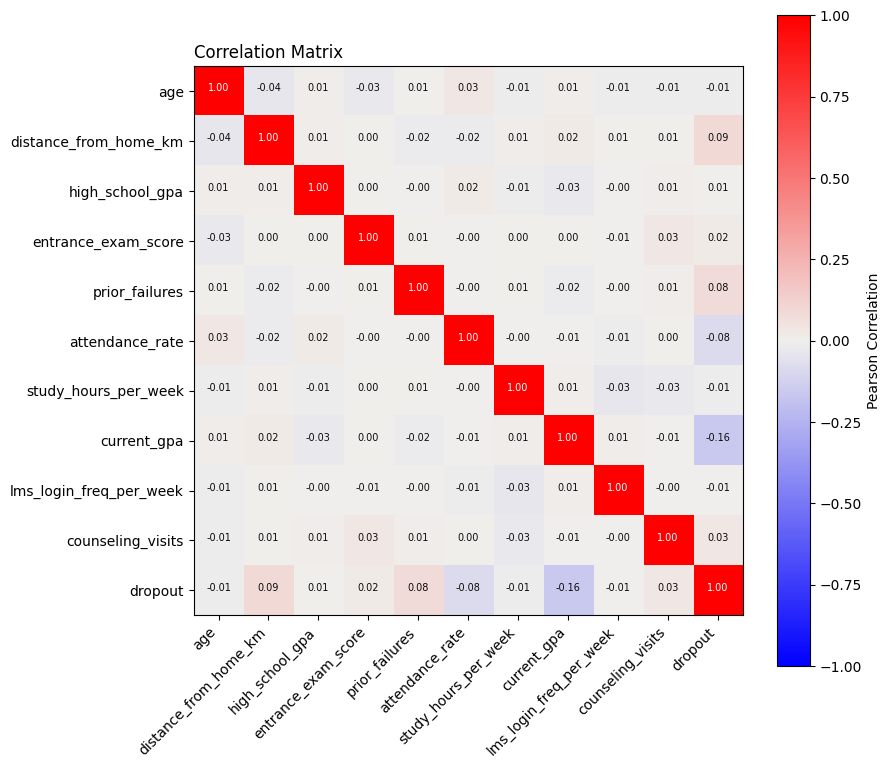

In [19]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    "div", ["blue", "#f0efec", "red"]
)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.values[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center",
            fontsize=7,
            color="#0b0b0b" if abs(value) < 0.6 else "#ffffff",
        )

plt.colorbar(im, ax=ax, label="Pearson Correlation")
ax.set_title("Correlation Matrix", loc="left")
plt.tight_layout()
plt.show()

In [20]:
print("Strongest correlations with dropout:")
print(
    corr["dropout"]
    .drop("dropout")
    .sort_values(key=abs, ascending=False)
    .round(2)
)

Strongest correlations with dropout:
current_gpa               -0.16
distance_from_home_km      0.09
attendance_rate           -0.08
prior_failures             0.08
counseling_visits          0.03
entrance_exam_score        0.02
age                       -0.01
study_hours_per_week      -0.01
lms_login_freq_per_week   -0.01
high_school_gpa            0.01
Name: dropout, dtype: float64


## Outlier Detection

In [21]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((series < lower) | (series > upper)).sum()

In [22]:
outlier_report = pd.Series({
    col: iqr_outlier_count(df[col])
    for col in numeric_cols
}).sort_values(ascending=False)

outlier_report.to_frame("outlier_count")

,outlier_count
distance_from_home_km,221
attendance_rate,35
prior_failures,34
current_gpa,31
counseling_visits,27
study_hours_per_week,17
entrance_exam_score,15
high_school_gpa,11
lms_login_freq_per_week,4
age,0


## Categorical Encoding

In [23]:
df_enc = pd.get_dummies(df, columns=cat_cols)

feature_cols = [
    c for c in df_enc.columns
    if c not in ("student_id", "dropout")
]

X = df_enc[feature_cols]
y = df_enc["dropout"]

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 25
X shape: (5000, 25)
y shape: (5000,)


## Train/Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


## Feature Scaling

In [25]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Model Selection and Training

In [26]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
    ),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_s, y_train)

    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]

    cv_auc = cross_val_score(
        model,
        X_train_s,
        y_train,
        cv=5,
        scoring="roc_auc",
    ).mean()

    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "cv_auc": cv_auc,
    }

Training logistic_regression...
Training random_forest...


## Model Evaluation

In [27]:
print(json.dumps(results, indent=2))

{
  "logistic_regression": {
    "accuracy": 0.649,
    "precision": 0.5063559322033898,
    "recall": 0.6694677871148459,
    "f1": 0.5765983112183354,
    "roc_auc": 0.7147344163170712,
    "cv_auc": 0.7059331718864793
  },
  "random_forest": {
    "accuracy": 0.657,
    "precision": 0.5216049382716049,
    "recall": 0.4733893557422969,
    "f1": 0.49632892804698975,
    "roc_auc": 0.6661918266529008,
    "cv_auc": 0.6852983592283203
  }
}


In [28]:
results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("roc_auc", ascending=False)
)

results_df

,accuracy,precision,recall,f1,roc_auc,cv_auc
logistic_regression,0.649,0.506356,0.669468,0.576598,0.714734,0.705933
random_forest,0.657,0.521605,0.473389,0.496329,0.666192,0.685298


## Select Best Model

In [29]:
best_name = max(
    results,
    key=lambda k: results[k]["roc_auc"],
)

best_model = models[best_name]

print(f"Best model: {best_name}")

Best model: logistic_regression


## Classification Report

In [30]:
best_predictions = best_model.predict(X_test_s)

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       0.78      0.64      0.70       643
           1       0.51      0.67      0.58       357

    accuracy                           0.65      1000
   macro avg       0.64      0.65      0.64      1000
weighted avg       0.68      0.65      0.66      1000



## Confusion Matrix

In [31]:
cm = confusion_matrix(y_test, best_predictions)
cm

array([[410, 233],
       [118, 239]])

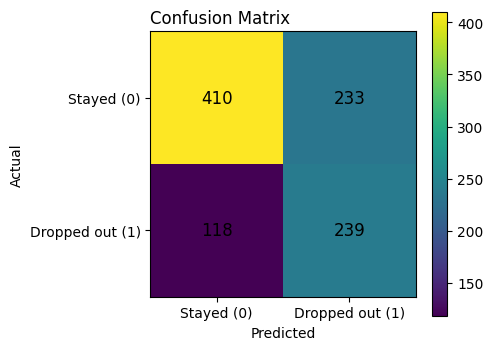

In [32]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Stayed (0)", "Dropped out (1)"])
ax.set_yticklabels(["Stayed (0)", "Dropped out (1)"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix", loc="left")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar(im)
plt.tight_layout()
plt.show()

## Save Model Artifacts

In [33]:
model_path = os.path.join(MODEL_DIR, "model.pkl")
scaler_path = os.path.join(MODEL_DIR, "scaler.pkl")
features_path = os.path.join(MODEL_DIR, "feature_cols.json")
metrics_path = os.path.join(MODEL_DIR, "metrics.json")

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)

with open(features_path, "w") as f:
    json.dump(feature_cols, f, indent=2)

with open(metrics_path, "w") as f:
    json.dump(
        {"best_model": best_name, "results": results},
        f,
        indent=2,
    )

print("Saved:")
print(model_path)
print(scaler_path)
print(features_path)
print(metrics_path)

Saved:
../model/model.pkl
../model/scaler.pkl
../model/feature_cols.json
../model/metrics.json


## Feature Importance

In [34]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances,
})

imp_df = (
    imp_df
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance", ascending=True)
)

imp_df

,feature,importance
19,has_scholarship_0,0.142963
20,has_scholarship_1,0.142963
17,parental_education_Postgraduate,0.144978
4,prior_failures,0.148785
6,attendance_rate,0.189273
16,parental_education_Bachelor,0.193262
1,distance_from_home_km,0.223925
13,family_income_level_High,0.294912
14,family_income_level_Low,0.310364
8,current_gpa,0.379493


## Plot Top 10 Dropout Prediction Features

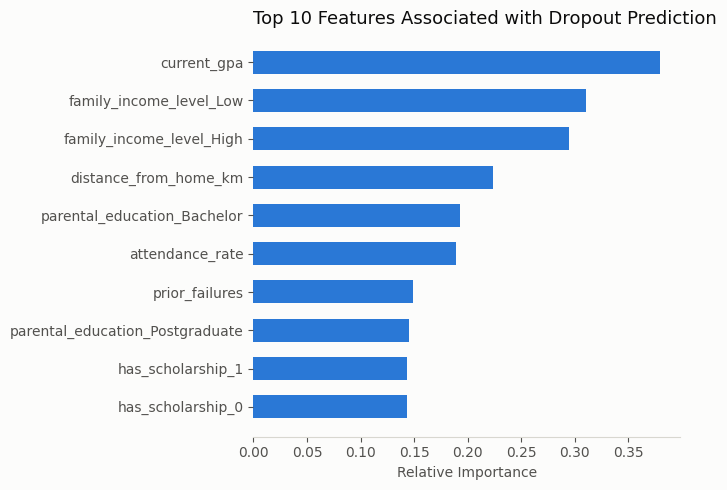

Feature importance plot saved to: ../static/feature_importance.png


In [35]:
fig, ax = plt.subplots(
    figsize=(7, 5),
    facecolor="#fcfcfb",
)

ax.set_facecolor("#fcfcfb")

ax.barh(
    imp_df["feature"],
    imp_df["importance"],
    color="#2a78d6",
    height=0.6,
)

ax.set_title(
    "Top 10 Features Associated with Dropout Prediction",
    color="#0b0b0b",
    fontsize=13,
    loc="left",
)

ax.tick_params(colors="#52514e")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#d8d7d0")

ax.set_xlabel(
    "Relative Importance",
    color="#52514e",
)

plt.tight_layout()

feature_plot_path = os.path.join(
    STATIC_DIR,
    "feature_importance.png",
)

plt.savefig(
    feature_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Feature importance plot saved to: {feature_plot_path}")